# CosmoFit Quickstart

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/main/examples/quickstart.ipynb)

The shortest path from "nothing installed" to a real MCMC posterior:
pick a model, pick datasets, fit. This notebook fits flat ΛCDM to
Cosmic Chronometers + DESI BAO in a couple of minutes.

For a deeper dive: [`cpl_mcmc_analysis.ipynb`](cpl_mcmc_analysis.ipynb)
(full CPL dark-energy analysis with convergence diagnostics, model
comparison and every figure), [`model_zoo_comparison.ipynb`](model_zoo_comparison.ipynb)
(all 6 cosmological models head-to-head), and
[`dataset_zoo.ipynb`](dataset_zoo.ipynb) (a tour of every built-in
dataset).

**Running this notebook:** open in Colab and *Runtime → Run all*.


## Setup

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("CosmoFit"):
        !git clone --quiet -b dev https://github.com/salihyesil59/CosmoFit.git
    %cd CosmoFit
    !pip install -q -e .

    # The editable install above runs in a subprocess, so the .pth /
    # editable-finder file it writes isn't picked up by *this*
    # already-running kernel without a restart. Without this, `import
    # CosmoFit` can resolve to the bare repo checkout directory
    # instead (same name as the package, and `/content` is on
    # sys.path in Colab) -- an empty namespace package with none of
    # LCDM/CPL/Fitter defined, raising a confusing "unknown location"
    # ImportError. Pointing sys.path at src/ directly sidesteps that.
    import importlib
    sys.path.insert(0, os.path.abspath("src"))
    importlib.invalidate_caches()
else:
    print("Not running in Colab -- assuming CosmoFit is already installed "
          "(pip install -e . from the repository root).")


Not running in Colab -- assuming CosmoFit is already installed (pip install -e . from the repository root).


## The whole workflow in one cell

`Fitter` ties together a cosmological model, a list of datasets, and
which parameters are free. Everything else -- likelihoods, priors,
the posterior, MCMC, plotting -- is built for you.

In [2]:
from CosmoFit import LCDM, Fitter

fit = Fitter(
    model=LCDM,
    datasets=["cc", "desi"],
    free_params=["H0", "Omega_m"],
    initial={"H0": 67.4, "Omega_m": 0.315, "rd": 147.1},
)

fit

Fitter(model=LCDM, datasets=['cc', 'desi'], free_params=['H0', 'Omega_m'])

In [3]:
fit.run_mcmc(nwalkers=24, nsteps=1500, burnin=300, seed=0, progress=True)

100%|██████████| 1500/1500 [00:07<00:00, 191.04it/s]


## Was that enough steps? Always check.

In [4]:
conv = fit.convergence()
print(f"converged: {conv['converged']}")
for name, tau in conv["tau"].items():
    print(f"  {name}: tau={tau:.1f}, n_eff={conv['n_effective'][name]:.0f}")

The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 24;
tau: [28.01249268 25.28483584]


converged: False
  H0: tau=28.0, n_eff=1028
  Omega_m: tau=25.3, n_eff=1139


## Results

In [5]:
for name, s in fit.summary().items():
    print(f"{name:>10s} = {s['median']:.4f} +{s['plus']:.4f} / -{s['minus']:.4f}")

fit.best_fit()
print(f"\nbest fit: {fit.best_fit_params}")
print(f"chi2_min = {fit.best_fit_chi2:.2f}  ({fit.n_data} data points)")

        H0 = 69.3449 +0.8267 / -0.8655
   Omega_m = 0.2933 +0.0148 / -0.0132

best fit: {'H0': np.float64(69.33754920058024), 'Omega_m': np.float64(0.29331232304684146)}
chi2_min = 25.71  (44 data points)


## Plots

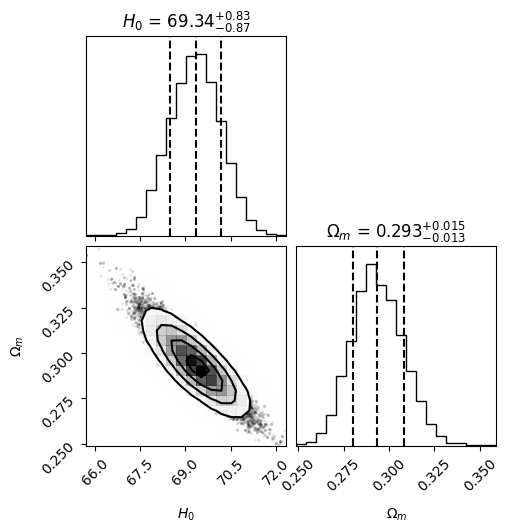

In [6]:
fig = fit.plots.corner()

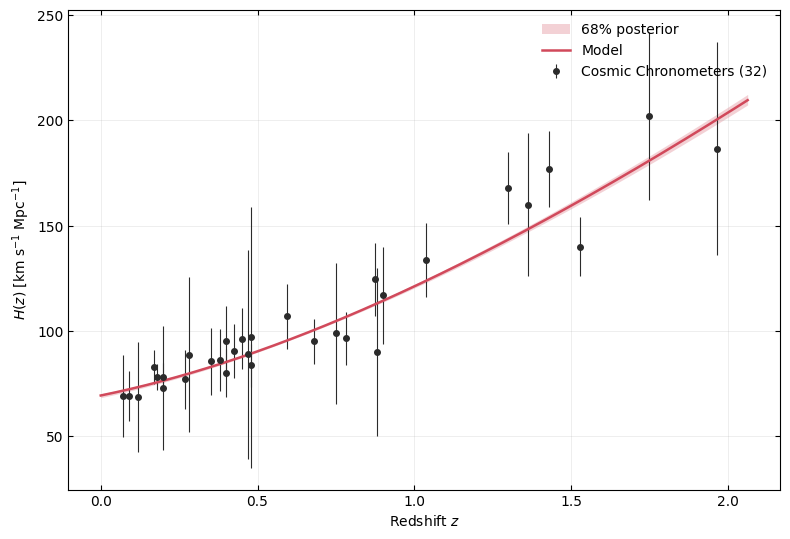

In [7]:
fig = fit.plots.hz()

## Next steps

- Swap `model=LCDM` for `CPL`, `WCDM`, `JBP`, `BA`, or `GCG` -- see
  [`model_zoo_comparison.ipynb`](model_zoo_comparison.ipynb) for all
  six side by side.
- Add `"pantheon"`, `"des_sn5yr"`, `"sdss_bao"`, or `"planck"` to
  `datasets=[...]` -- see [`dataset_zoo.ipynb`](dataset_zoo.ipynb)
  for what each one looks like on its own (and which combinations to
  avoid).
- `fit.plots` has a lot more than `corner()`/`hz()`: try
  `hubble_diagram()`, `bao_distances()`, `w_of_z()`,
  `deceleration()`.